# Telco Customer Churn Prediction using Neural Networks

## Problem Statement

Customer churn is a critical challenge in the telecommunications industry, as losing customers directly impacts revenue. This project aims to analyze customer behavior and build a predictive model to identify customers who are likely to churn.

The problem is formulated as a binary classification task, where the goal is to predict whether a customer will discontinue the service (churn) based on their demographic and service-related features.



## Importing Libraries

The following libraries are used for data manipulation, visualization, and model building:

- Pandas and NumPy for data handling
- Matplotlib and Seaborn for visualization
- Scikit-learn for preprocessing and evaluation
- TensorFlow/Keras for building the neural network model


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


## Data Loading and Understanding

The dataset contains customer-level information from a telecommunications service provider. Each row represents a customer, and the target variable indicates whether the customer has churned.

The dataset includes both numerical and categorical features such as tenure, monthly charges, contract type, and internet service.

In [ ]:
df = pd.read_csv("telco_churn.csv")
df.shape

(7043, 21)

In [ ]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [ ]:
df.describe()


,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


## Data Preprocessing

The dataset was cleaned and prepared to ensure consistency and suitability for modeling.
Missing values can negatively impact model performance and lead to biased results. Therefore, identifying and handling them is a crucial preprocessing step.

- Column names were standardized by removing leading and trailing whitespace.
- The `TotalCharges` column was converted to numeric format, and missing values were removed.
- The `customerID` column was dropped as it is a unique identifier and does not contribute to prediction.
- Duplicate records were identified and removed to avoid bias.


In [ ]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [ ]:
# Standardize column names
df.columns = df.columns.str.strip()

# Remove ID column
df = df.drop('customerID', axis=1)


In [ ]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df = df.dropna()

In [ ]:
df.dtypes

,0
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object
OnlineSecurity,object
OnlineBackup,object


In [ ]:
df.duplicated().sum()

np.int64(22)

In [ ]:
df = df.drop_duplicates()

In [ ]:
df.duplicated().sum()

np.int64(0)

## Churn Distribution

To understand the target variable, the distribution of churn was analyzed. This helps identify whether the dataset is balanced or imbalanced, which is important for model evaluation.

The results show that the number of customers who did not churn is higher than those who churned, indicating a moderately imbalanced dataset. This imbalance can affect model performance, particularly in detecting churn cases.

In [ ]:
df['Churn'].value_counts()

,count
Churn,
No,5153
Yes,1857


## Exploratory Data Analysis (EDA)

Exploratory Data Analysis was conducted to understand customer behavior and identify key factors influencing churn. The goal was to uncover meaningful patterns that can guide both model development and business decisions.

### Churn Distribution
The dataset shows a moderately imbalanced distribution, with fewer churn cases compared to non-churn. This indicates that accuracy alone may not be sufficient for evaluating model performance, and metrics such as recall are important for identifying churn cases.

---

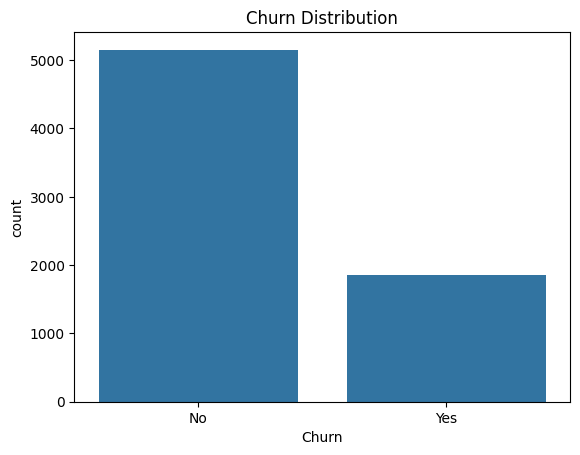

In [ ]:
sns.countplot(x='Churn', data=df)
plt.title("Churn Distribution")
plt.show()

### Insight 1: Contract Type and Churn
Customers with month-to-month contracts exhibit significantly higher churn rates compared to those with one-year or two-year contracts. This suggests that customers with lower commitment levels are more likely to discontinue the service.

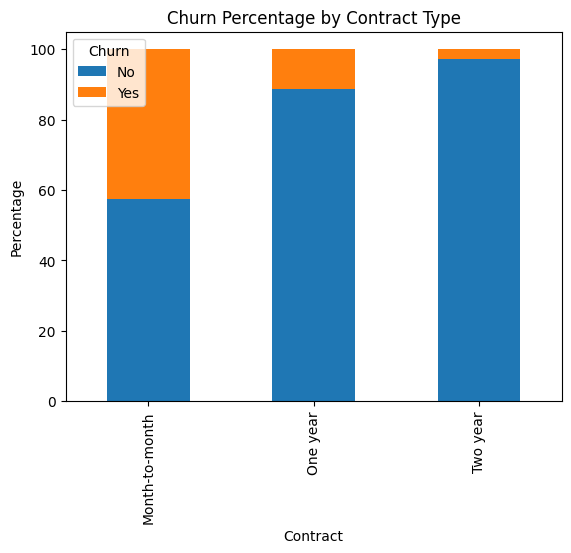

In [ ]:
contract_churn = pd.crosstab(df['Contract'], df['Churn'], normalize='index') * 100

contract_churn.plot(kind='bar', stacked=True)
plt.title("Churn Percentage by Contract Type")
plt.ylabel("Percentage")
plt.show()


### Insight 2: Tenure and Churn
Customers with lower tenure are more likely to churn, indicating that the risk of churn is highest during the early stages of the customer lifecycle. This highlights the importance of onboarding and early engagement strategies.


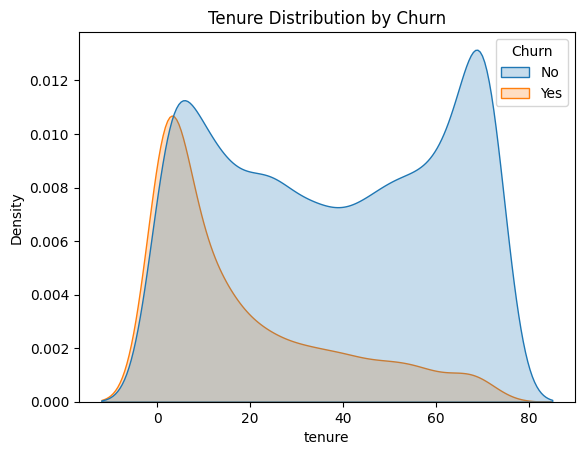

In [ ]:
sns.kdeplot(data=df, x='tenure', hue='Churn', fill=True)
plt.title("Tenure Distribution by Churn")
plt.show()


### Insight 3: Internet Service and Churn
Customers using fiber optic internet services show higher churn rates compared to DSL and non-internet users. This may be due to higher expectations from premium services, where dissatisfaction can lead to increased churn.


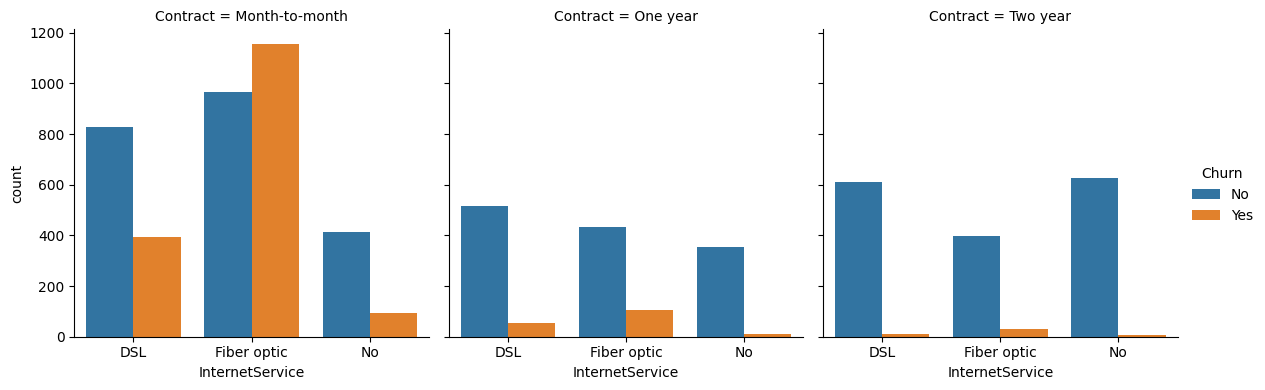

In [ ]:
sns.catplot(x='InternetService', hue='Churn', col='Contract',
            data=df, kind='count', height=4, aspect=1)


### Insight 4: Monthly Charges and Churn
Customers with higher monthly charges tend to have higher churn rates. This suggests that pricing plays a critical role in customer retention, and customers may leave if they perceive the service as expensive relative to its value.

---

/tmp/ipykernel_574/3534032067.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


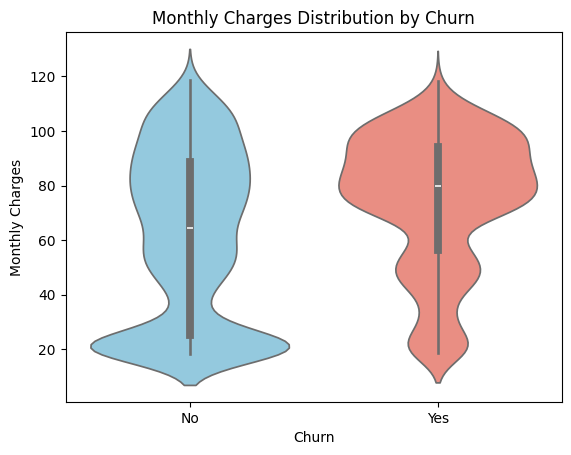

In [ ]:
sns.violinplot(
    x='Churn',
    y='MonthlyCharges',
    data=df,
    palette={'No': 'skyblue', 'Yes': 'salmon'}
)

plt.title("Monthly Charges Distribution by Churn")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")
plt.show()

### Correlation Analysis

A correlation heatmap was used to examine relationships between numerical features in the dataset. This helps identify how variables such as tenure, monthly charges, and total charges are related to each other.

The analysis shows that tenure and total charges are positively correlated, indicating that customers who stay longer tend to accumulate higher total charges. Additionally, tenure shows an indirect relationship with churn, where longer-tenured customers are less likely to churn.

While correlation does not imply causation, these relationships provide useful insights for feature selection and model development.

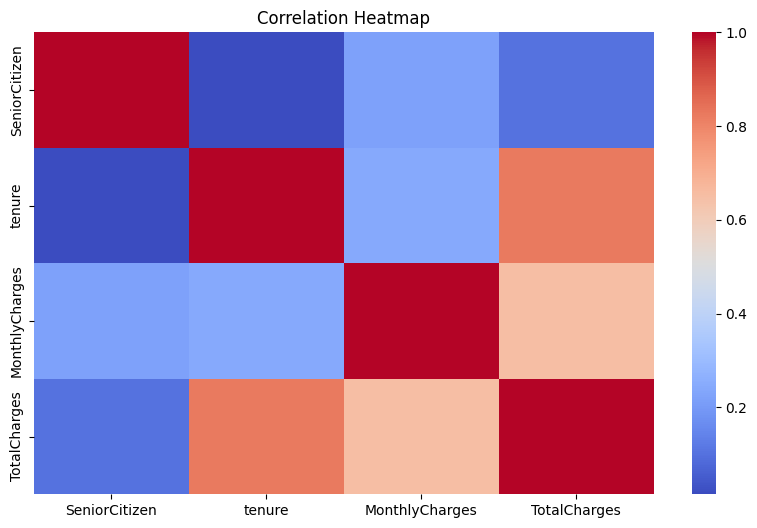

In [ ]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

### Summary of Key Insights
- Low commitment (month-to-month contracts) increases churn risk  
- New customers (low tenure) are more likely to churn  
- Higher monthly charges are associated with increased churn  
- Fiber optic users represent a high-risk, high-value segment  

These insights were used to guide feature selection and inform business decisions aimed at reducing customer churn.

## Feature Selection and Data Preparation

Based on the insights obtained from exploratory data analysis, several features were identified as important predictors of customer churn. In particular, variables such as tenure, contract type, monthly charges, and internet service showed strong relationships with churn behavior.

To prepare the data for modeling, categorical variables were transformed using one-hot encoding to convert them into a numerical format suitable for machine learning algorithms. The target variable was encoded as a binary variable representing churn (1) and non-churn (0).

The dataset was then split into input features (X) and target variable (y). A train-test split was performed to evaluate model performance on unseen data.

Finally, feature scaling was applied using standardization to ensure that numerical variables are on a similar scale. This is particularly important for neural networks, as it improves training stability and convergence while preventing data leakage by fitting the scaler only on the training data.

In [ ]:
df = pd.get_dummies(df, drop_first=True)

In [ ]:
X = df.drop('Churn_Yes', axis=1)
y = df['Churn_Yes']

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## Neural Network Model

A feedforward neural network was implemented to model the relationship between customer features and churn. The model architecture was kept simple to ensure interpretability while still capturing non-linear patterns in the data.

The network consists of two hidden layers with 16 and 8 neurons respectively, using ReLU activation functions. These layers help the model learn complex relationships between input features.

The output layer uses a sigmoid activation function, which produces a probability between 0 and 1 for binary classification. Binary cross-entropy was used as the loss function, as it is well-suited for binary classification problems.

The Adam optimizer was selected for efficient training and faster convergence. Early stopping was applied to prevent overfitting by monitoring validation loss and stopping training when performance no longer improves.

This architecture provides a balance between simplicity and predictive capability, aligning with the objective of focusing on interpretation rather than model complexity.

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input

model = Sequential()

model.add(Input(shape=(X_train.shape[1],)))
model.add(Dense(16, activation='relu'))
model.add(Dense(8, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

In [ ]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

## Model Training

The neural network model was trained using the training dataset to learn patterns associated with customer churn.

The model was trained for a fixed number of epochs with a defined batch size to ensure stable and efficient learning. A validation split was used to monitor the model's performance on unseen data during training.

Early stopping was applied to prevent overfitting by stopping the training process when the validation loss stopped improving. This helps in maintaining a balance between underfitting and overfitting.

The training process allows the model to iteratively adjust its weights and improve its predictions over time.

In [ ]:
history = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7227 - loss: 0.5305 - val_accuracy: 0.7602 - val_loss: 0.4797
Epoch 2/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7798 - loss: 0.4593 - val_accuracy: 0.7745 - val_loss: 0.4555
Epoch 3/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7860 - loss: 0.4430 - val_accuracy: 0.7807 - val_loss: 0.4466
Epoch 4/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7914 - loss: 0.4363 - val_accuracy: 0.7816 - val_loss: 0.4423
Epoch 5/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7938 - loss: 0.4314 - val_accuracy: 0.7861 - val_loss: 0.4395
Epoch 6/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7956 - loss: 0.4282 - val_accuracy: 0.7906 - val_loss: 0.4369
Epoch 7/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7963 - loss: 0.4253 - val_accuracy: 0.7870 - val_loss: 0.4374
Epoch 8/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7983 - loss: 0.4242 - val_accuracy: 0.

In [ ]:
y_pred = (model.predict(X_test) > 0.5).astype(int)

44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


## Model Evaluation

The model was evaluated using multiple metrics to assess its performance in predicting customer churn.

The overall accuracy of the model is approximately 81%, indicating good general performance. However, due to class imbalance, accuracy alone is not sufficient to evaluate the model.

The confusion matrix provides a detailed breakdown of predictions. The model performs well in identifying non-churn customers but shows limitations in detecting churn cases.

The recall for churn is approximately 57%, meaning that a significant proportion of customers who actually churn are not identified by the model. This is critical from a business perspective, as these missed cases represent potential revenue loss.

Precision, recall, and F1-score were used to better understand model performance. In this context, recall is particularly important, as identifying at-risk customers is more valuable than avoiding false alarms.

Overall, the model captures general patterns effectively but requires improvement in detecting churn cases.

In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print(cm)

[[952 129]
 [137 184]]


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

       False       0.87      0.88      0.88      1081
        True       0.59      0.57      0.58       321

    accuracy                           0.81      1402
   macro avg       0.73      0.73      0.73      1402
weighted avg       0.81      0.81      0.81      1402



In [ ]:
model.evaluate(X_test, y_test)

44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8103 - loss: 0.3973


[0.39725083112716675, 0.8102710247039795]

## Business Decisions and Recommendations

### Decision 1: Focus on Early-Stage Customers

Customers with low tenure show higher churn rates. Therefore, targeted onboarding and engagement strategies should be implemented during the initial months.

Risk: Increased cost of retention programs  
Assumption: Early dissatisfaction drives churn

### Decision 2: Retain High-Value Customers

Customers with high monthly charges, especially fiber users, exhibit higher churn. Retention strategies such as loyalty discounts and service improvements should be applied.

Risk: Reduced profit margins  
Assumption: Churn is driven by pricing and service dissatisfaction